# Prediction Model (Ranking-Based Popularity)

Predicting collaboration success (`log_streams`) using:
- **Ranking-based popularity** (`log_ranking_score_source/target`) instead of streams
- Hyperbolic distance
- Collaboration frequency (weight)
- Market and year

## 1. Imports & Data Loading

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')


DATASET = 'model_dataset.csv'
TARGET = 'log_streams'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

df = pd.read_csv(DATASET)
df = df.dropna(subset=['log_ranking_score_source', 'log_ranking_score_target'])

le_market = LabelEncoder()
df['market_enc'] = le_market.fit_transform(df['market'])

FEATURES = [
    'distance',
    'log_ranking_score_source',  
    'log_ranking_score_target', 
    'log_weight',
    'market_enc',
    'year'
]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['market']
)

print(f"\nTrain set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")
print(f"\nFeatures: {FEATURES}")
print(f"Target: {TARGET}")


Train set: 34,928 samples
Test set:  8,733 samples

Features: ['distance', 'log_ranking_score_source', 'log_ranking_score_target', 'log_weight', 'market_enc', 'year']
Target: log_streams


In [ ]:
DATASET = 'model_dataset.csv'
TARGET = 'log_streams'

df = pd.read_csv(DATASET)
df = df.dropna(subset=['log_ranking_score_source', 'log_ranking_score_target'])

le_market = LabelEncoder()
df['market_enc'] = le_market.fit_transform(df['market'])

FEATURES = [
    'distance',
    'log_ranking_score_source',  
    'log_ranking_score_target', 
    'log_weight',
    'market_enc',
    'year'
]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['market']
)

FEATURES_NO_DIST = [
    'log_ranking_score_source',
    'log_ranking_score_target',
    'log_weight',
    'market_enc',
    'year'
]
FEATURES_WITH_DIST = FEATURES


FEATURES_RANKING = ['distance', 'log_ranking_score_source', 
                    'log_ranking_score_target', 'log_weight', 
                    'market_enc', 'year']

FEATURES_STREAMS = ['distance', 'log_popularity_source', 
                    'log_popularity_target', 'log_weight', 
                    'market_enc', 'year']

X_train_no_dist = X_train[FEATURES_NO_DIST]
X_test_no_dist = X_test[FEATURES_NO_DIST]


print(f"\nTrain set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")
print(f"\nFeatures: {FEATURES}")
print(f"Target: {TARGET}")


Train set: 34,928 samples
Test set:  8,733 samples

Features: ['distance', 'log_ranking_score_source', 'log_ranking_score_target', 'log_weight', 'market_enc', 'year']
Target: log_streams


## 2. Model Comparison with Hyperparameter Tuning

We compare three models, each with hyperparameter tuning:
- **Linear Regression** (Ridge) - tune alpha
- **Random Forest** - tune n_estimators, max_depth, min_samples_split, min_samples_leaf
- **Gradient Boosting** - tune n_estimators, max_depth, learning_rate, subsample

**Process:**
1. Randomized search with 3-fold CV to find best hyperparameters (20 iterations)
2. Evaluate best model with 5-fold CV on training set
3. Test on held-out test set

**Metrics:** 5-fold CV R² and Test R²

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Linear Regression
ridge_params = {
    'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]
}

# 2. Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Gradient Boosting
gb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

models_params = {
    'Linear Regression': (Ridge(random_state=42), ridge_params),
    'Random Forest': (RandomForestRegressor(random_state=42, n_jobs=-1), rf_params),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42), gb_params)
}

results = {}

print("="*70)
print("HYPERPARAMETER TUNING AND MODEL EVALUATION")
print("="*70)

for name, (model, params) in models_params.items():
    print(f"\n{name}:")
    print(f"  Tuning hyperparameters with 3-fold CV...")
    
    # Randomized search with 3-fold CV for tuning
    search = RandomizedSearchCV(
        model, params, n_iter=20, cv=3, scoring='r2',
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)
    
    print(f"  Best params: {search.best_params_}")
    
    # Using best model for 5-fold CV evaluation
    best_model = search.best_estimator_
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, 
                                scoring='r2', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    print(f"  5-fold CV R²: {cv_mean:.4f} (±{cv_std:.4f})")
    
    # Testing set performance
    y_pred_test = best_model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    print(f"  Test R²:      {test_r2:.4f}")
    
    results[name] = {
        'model': best_model,
        'best_params': search.best_params_,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'test_r2': test_r2,
        'y_pred': y_pred_test
    }

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY (After Hyperparameter Tuning)")
print("="*70)
print(f"{'Model':<20} {'5-Fold CV R²':<20} {'Test R²':<15}")
print("-"*70)
for name, res in results.items():
    print(f"{name:<20} {res['cv_mean']:.4f} (±{res['cv_std']:.4f})    {res['test_r2']:.4f}")

best_model_name = max(results, key=lambda k: results[k]['test_r2'])
best_model = results[best_model_name]['model']
best_test_r2 = results[best_model_name]['test_r2']
best_y_pred = results[best_model_name]['y_pred']
best_params = results[best_model_name]['best_params']

print("\n" + "="*70)
print(f"BEST MODEL: {best_model_name} (Test R² = {best_test_r2:.4f})")
print(f"Best parameters: {best_params}")
print("="*70)

HYPERPARAMETER TUNING AND MODEL EVALUATION

Linear Regression:
  Tuning hyperparameters with 3-fold CV...
  Best params: {'alpha': 10.0}
  5-fold CV R²: 0.1540 (±0.0063)
  Test R²:      0.1487

Random Forest:
  Tuning hyperparameters with 3-fold CV...


Exception ignored in: <function ResourceTracker.__del__ at 0x110571bc0>
Traceback (most recent call last):
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107165bc0>
Traceback (most recent call last):
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [E

  Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
  5-fold CV R²: 0.6394 (±0.0050)
  Test R²:      0.6552

Gradient Boosting:
  Tuning hyperparameters with 3-fold CV...


Exception ignored in: <function ResourceTracker.__del__ at 0x111c41bc0>
Traceback (most recent call last):
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x109771bc0>
Traceback (most recent call last):
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [E

  Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}
  5-fold CV R²: 0.6782 (±0.0010)
  Test R²:      0.6840

MODEL COMPARISON SUMMARY (After Hyperparameter Tuning)
Model                5-Fold CV R²         Test R²        
----------------------------------------------------------------------
Linear Regression    0.1540 (±0.0063)    0.1487
Random Forest        0.6394 (±0.0050)    0.6552
Gradient Boosting    0.6782 (±0.0010)    0.6840

BEST MODEL: Gradient Boosting (Test R² = 0.6840)
Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}


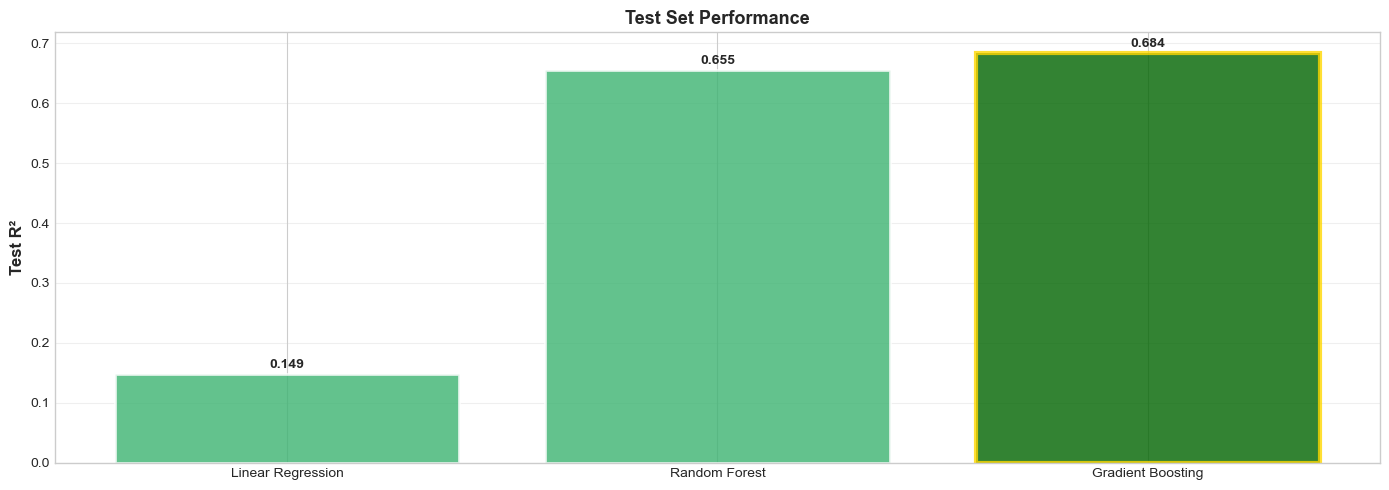

In [ ]:
fig, (ax2) = plt.subplots(figsize=(14, 5))

model_names = list(results.keys())
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds = [results[m]['cv_std'] for m in model_names]
test_r2s = [results[m]['test_r2'] for m in model_names]

bars = ax2.bar(model_names, test_r2s, 
               color='mediumseagreen', edgecolor='white', linewidth=2, alpha=0.8)
best_idx = model_names.index(best_model_name)
bars[best_idx].set_color('darkgreen')
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

ax2.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax2.set_title('Test Set Performance', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, r2 in enumerate(test_r2s):
    ax2.text(i, r2 + 0.01, f'{r2:.3f}',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Best Model Analysis

Detailed analysis of the best-performing model.

Feature Importance:
                 feature  importance
              market_enc    0.601744
log_ranking_score_source    0.110590
                distance    0.101401
log_ranking_score_target    0.097850
              log_weight    0.059344
                    year    0.029072


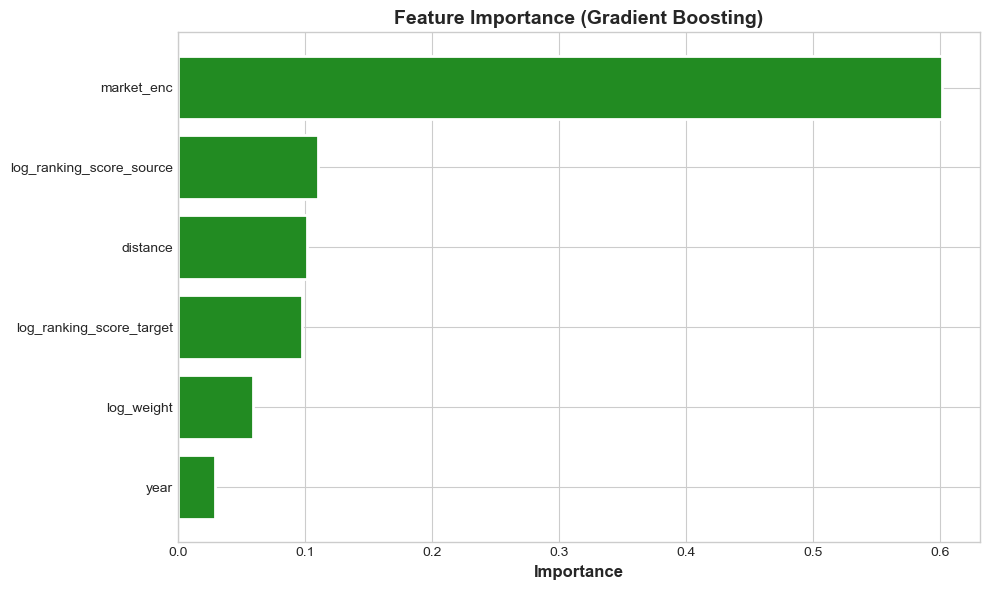

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    # Tree-based models
    feature_importance = pd.DataFrame({
        'feature': FEATURES,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Feature Importance:")
    print(feature_importance.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feature_importance['feature'], feature_importance['importance'],
            color='forestgreen', edgecolor='white', linewidth=2)
    ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
    ax.set_title(f'Feature Importance ({best_model_name})',
                 fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
elif hasattr(best_model, 'coef_'):
    # Linear models
    coefficients = pd.DataFrame({
        'feature': FEATURES,
        'coefficient': best_model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print("Model Coefficients:")
    print(coefficients.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in coefficients['coefficient']]
    ax.barh(coefficients['feature'], coefficients['coefficient'],
            color=colors, edgecolor='white', linewidth=2, alpha=0.7)
    ax.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    ax.set_title(f'Model Coefficients ({best_model_name})',
                 fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

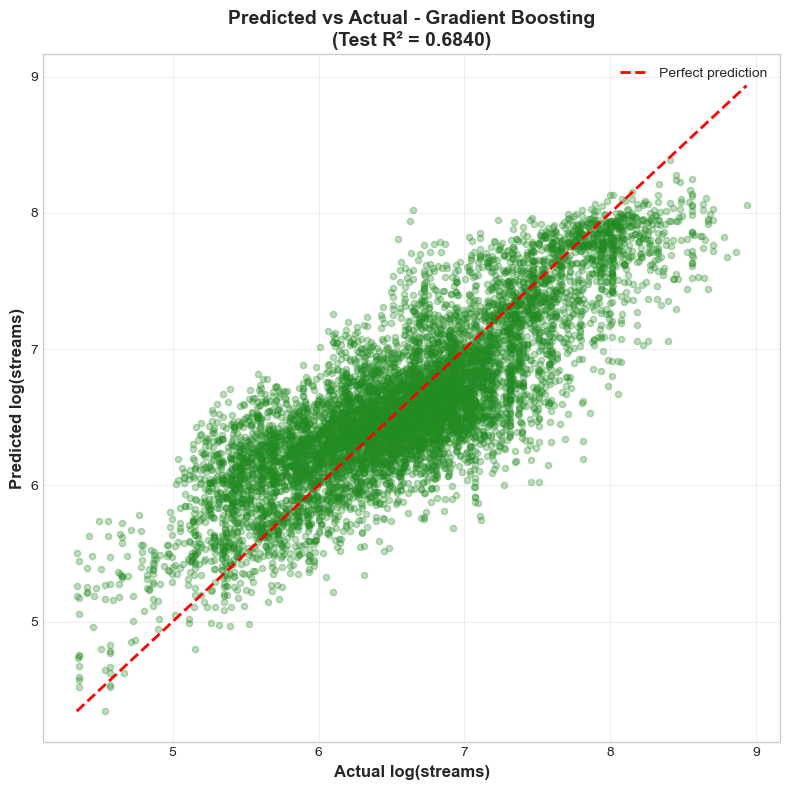

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, best_y_pred, alpha=0.3, s=20, color='forestgreen')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='Perfect prediction')

ax.set_xlabel('Actual log(streams)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted log(streams)', fontsize=12, fontweight='bold')
ax.set_title(f'Predicted vs Actual - {best_model_name}\n(Test R² = {best_test_r2:.4f})',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Explaining HOW Distance Improves Predictions

If distance helps, we need to understand:
- Does it help more for **similar genres** (low distance) or **diverse genres** (high distance)?
- Does distance boost or penalize predictions?
- What can we say about the relationship between distance and success?

Training comparison model WITHOUT distance feature...
  CV R²:   0.658 (±0.002)
  Test R²: 0.665

Testing statistical significance of improvement...
  t-statistic: 6.9804
  p-value:     0.000000
  Significant: Yes (p < 0.05)

Analyzing where distance provides most value...
ERROR REDUCTION BY DISTANCE LEVEL

Average error improvement (positive = distance helps):

                    mean  count
distance_group                 
Low             0.000817   2911
Medium          0.004989   2914
High            0.015829   2908

INTERPRETATION

✓ Distance helps MORE for DIVERSE collaborations (high distance)
  → The model learns unique patterns for genre-diverse pairs
  → Without distance, diverse collaborations are harder to predict



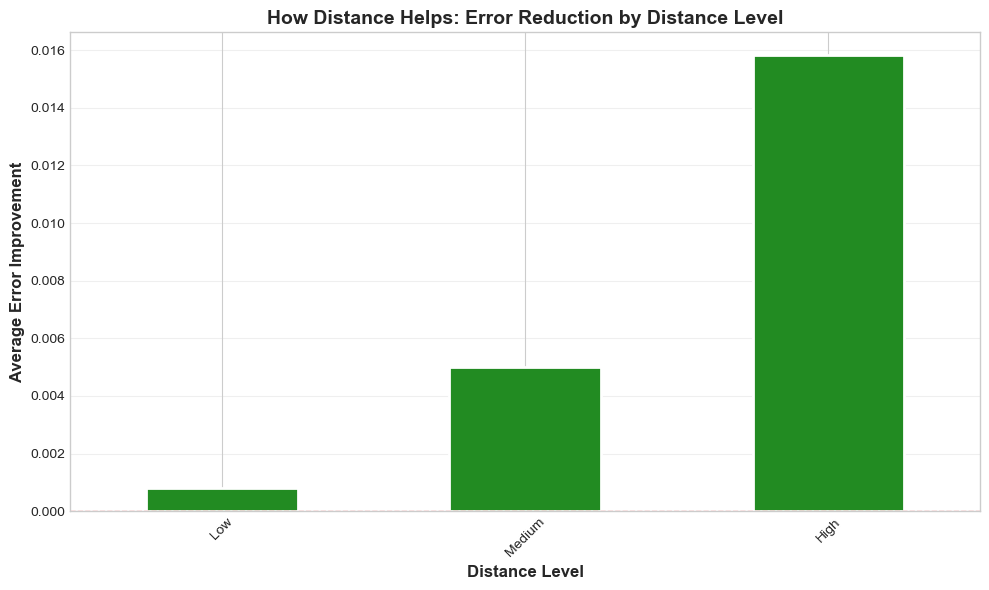

In [10]:
# ============================================================================
# ERROR REDUCTION ANALYSIS: How Distance Helps Predictions
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Train model WITHOUT distance for comparison
# ----------------------------------------------------------------------------
print("Training comparison model WITHOUT distance feature...")

if best_model_name == 'Linear Regression':
    model_no_dist = Ridge(**best_params, random_state=42)
elif best_model_name == 'Random Forest':
    model_no_dist = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
else: 
    model_no_dist = GradientBoostingRegressor(**best_params, random_state=42)

# Cross-validation
cv_scores_no_dist = cross_val_score(
    model_no_dist, X_train_no_dist, y_train,
    cv=5, scoring='r2', n_jobs=-1
)
cv_mean_no_dist = cv_scores_no_dist.mean()
cv_std_no_dist = cv_scores_no_dist.std()

# Train and predict
model_no_dist.fit(X_train_no_dist, y_train)
y_pred_no_dist = model_no_dist.predict(X_test_no_dist)
r2_no_dist = r2_score(y_test, y_pred_no_dist)

print(f"  CV R²:   {cv_mean_no_dist:.3f} (±{cv_std_no_dist:.3f})")
print(f"  Test R²: {r2_no_dist:.3f}")
print()

# ----------------------------------------------------------------------------
# 2. Statistical significance test (paired t-test)
# ----------------------------------------------------------------------------
print("Testing statistical significance of improvement...")

# Compute squared errors for both models
residuals_no_dist = y_test.values - y_pred_no_dist
residuals_with_dist = y_test.values - best_y_pred

mse_no_dist = residuals_no_dist ** 2
mse_with_dist = residuals_with_dist ** 2

# Paired t-test
t_stat, p_value = scipy_stats.ttest_rel(mse_no_dist, mse_with_dist)

print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_value:.6f}")
print(f"  Significant: {'Yes (p < 0.05)' if p_value < 0.05 else 'No'}")
print()

# ----------------------------------------------------------------------------
# 3. Analyze error reduction by distance level
# ----------------------------------------------------------------------------
print("Analyzing where distance provides most value...")

# Create analysis dataframe
test_analysis = pd.DataFrame({
    'distance': X_test['distance'].values,
    'actual': y_test.values,
    'pred_no_dist': y_pred_no_dist,
    'pred_with_dist': best_y_pred,
    'error_no_dist': np.abs(y_test.values - y_pred_no_dist),
    'error_with_dist': np.abs(y_test.values - best_y_pred)
})

# Calculate improvement (positive = distance helps)
test_analysis['improvement'] = (
    test_analysis['error_no_dist'] - test_analysis['error_with_dist']
)

# Group by distance level
test_analysis['distance_group'] = pd.qcut(
    test_analysis['distance'], 
    q=3,
    labels=['Low', 'Medium', 'High']
)

# ----------------------------------------------------------------------------
# 4. Results summary
# ----------------------------------------------------------------------------
print("=" * 70)
print("ERROR REDUCTION BY DISTANCE LEVEL")
print("=" * 70)
print()
print("Average error improvement (positive = distance helps):")
print()

improvement_by_distance = test_analysis.groupby('distance_group')['improvement'].agg([
    'mean', 'count'
])
print(improvement_by_distance.to_string())
print()

# ----------------------------------------------------------------------------
# 5. Interpretation
# ----------------------------------------------------------------------------
print("=" * 70)
print("INTERPRETATION")
print("=" * 70)
print()

low_improvement = improvement_by_distance.loc['Low', 'mean']
high_improvement = improvement_by_distance.loc['High', 'mean']

if high_improvement > low_improvement + 0.01:
    print("✓ Distance helps MORE for DIVERSE collaborations (high distance)")
    print("  → The model learns unique patterns for genre-diverse pairs")
    print("  → Without distance, diverse collaborations are harder to predict")
elif low_improvement > high_improvement + 0.01:
    print("✓ Distance helps MORE for SIMILAR collaborations (low distance)")
    print("  → The model learns that genre similarity enhances prediction")
    print("  → Without distance, the model misses similarity advantages")
else:
    print("✓ Distance helps UNIFORMLY across all diversity levels")
    print("  → Distance provides consistent additional signal")
print()

# ----------------------------------------------------------------------------
# 6. Visualization
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

improvement_by_distance['mean'].plot(
    kind='bar', 
    ax=ax, 
    color='forestgreen',
    edgecolor='white', 
    linewidth=2
)

ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Distance Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Error Improvement', fontsize=12, fontweight='bold')
ax.set_title(
    'How Distance Helps: Error Reduction by Distance Level',
    fontsize=14, 
    fontweight='bold'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)

DIRECTIONALITY: Does Distance Favor Similar or Diverse Pairs?

Average change in predictions when adding distance:
(Positive = distance increases predicted success)

distance_group
Low       0.002970
Medium    0.025565
High     -0.022004

Correlation(distance, prediction_change): -0.0590

OVERALL FINDING
Adding distance BOOSTS predictions for SIMILAR pairs
→ Lower distance → Higher predicted success
→ Interpretation: The model learns that similar genre pairs perform better


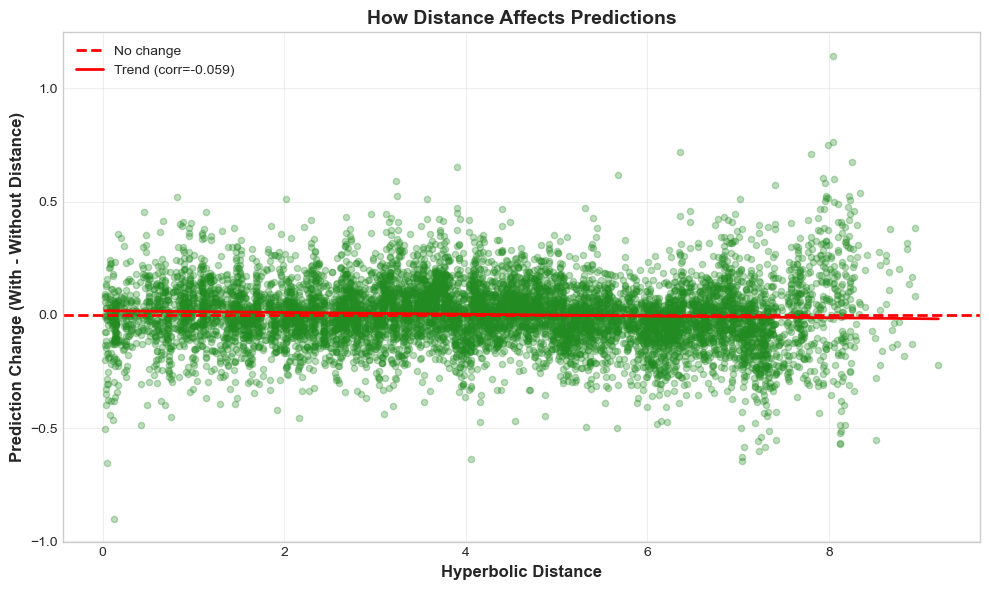

In [11]:
# Analysis 2: Directionality - does distance boost or penalize?

test_analysis['prediction_change'] = best_y_pred - y_pred_no_dist

print("="*70)
print("DIRECTIONALITY: Does Distance Favor Similar or Diverse Pairs?")
print("="*70)

direction_by_distance = test_analysis.groupby('distance_group')['prediction_change'].mean()

print("\nAverage change in predictions when adding distance:")
print("(Positive = distance increases predicted success)")
print()
print(direction_by_distance.to_string())

corr_dist_change = test_analysis[['distance', 'prediction_change']].corr().iloc[0, 1]

print(f"\nCorrelation(distance, prediction_change): {corr_dist_change:.4f}")

print("\n" + "="*70)
print("OVERALL FINDING")
print("="*70)

if corr_dist_change > 0.05:
    print("Adding distance BOOSTS predictions for DIVERSE pairs")
    print("→ Higher distance → Higher predicted success")
    print("→ Interpretation: The model learns that diverse collabs are undervalued by ranking alone")
elif corr_dist_change < -0.05:
    print("Adding distance BOOSTS predictions for SIMILAR pairs")
    print("→ Lower distance → Higher predicted success")
    print("→ Interpretation: The model learns that similar genre pairs perform better")
else:
    print("Distance effect is COMPLEX (non-linear relationship)")
    print("→ Not a simple 'more diverse = better' or 'more similar = better'")
    print("→ Distance helps calibrate predictions based on genre pair characteristics")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(test_analysis['distance'], test_analysis['prediction_change'],
          alpha=0.3, s=20, color='forestgreen')
ax.axhline(0, color='red', linestyle='--', linewidth=2, label='No change')

z = np.polyfit(test_analysis['distance'], test_analysis['prediction_change'], 1)
p = np.poly1d(z)
ax.plot(test_analysis['distance'].sort_values(),
       p(test_analysis['distance'].sort_values()),
       'r-', linewidth=2, label=f'Trend (corr={corr_dist_change:.3f})')

ax.set_xlabel('Hyperbolic Distance', fontsize=12, fontweight='bold')
ax.set_ylabel('Prediction Change (With - Without Distance)',
             fontsize=12, fontweight='bold')
ax.set_title('How Distance Affects Predictions',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparison: Ranking vs Streams-Based Popularity

Compare ranking-based model with streams-based model using the best model architecture.


SUMMARY

Metric                    Ranking-Based        Streams-Based        Difference     
----------------------------------------------------------------------
5-Fold CV R²              0.6782 (±0.0010)   0.6697 (±0.0040)   +0.0085
Test R²                   0.6840               0.6776               +0.0064

Paired t-test on squared errors:
  t-statistic: 2.7248
  p-value:     0.0064

→ RANKING-based is SIGNIFICANTLY BETTER


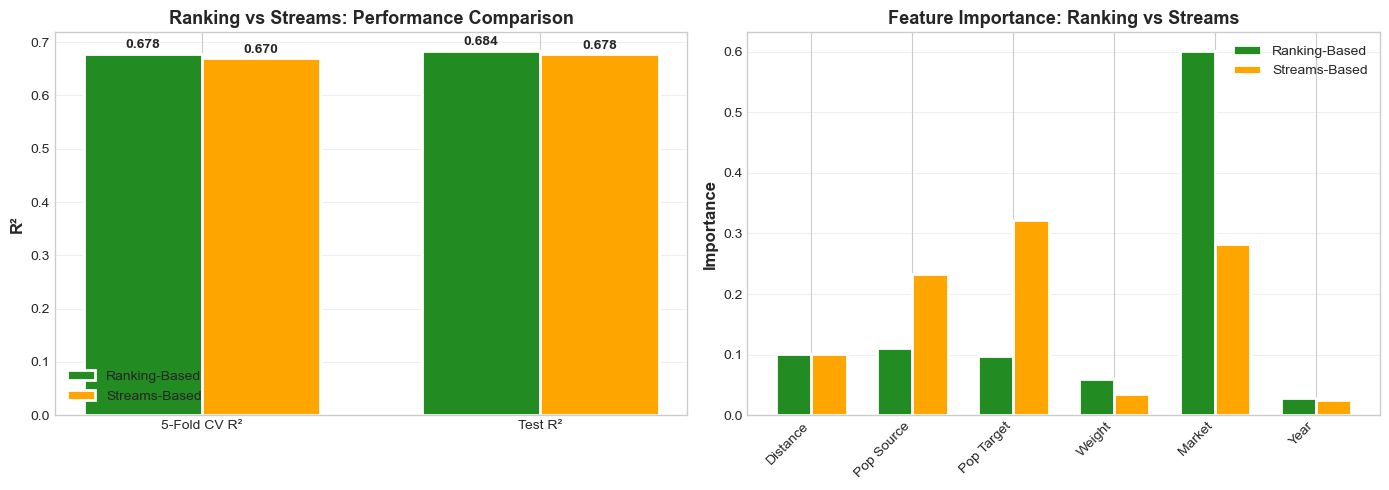

In [12]:
df_full = pd.read_csv(DATASET)
df_comp = df_full.dropna(subset=['log_ranking_score_source', 
                                  'log_ranking_score_target'])


le_comp = LabelEncoder()
df_comp['market_enc'] = le_comp.fit_transform(df_comp['market'])

X_ranking = df_comp[FEATURES_RANKING]
X_streams = df_comp[FEATURES_STREAMS]
y_comp = df_comp[TARGET]

X_train_r, X_test_r, y_train_c, y_test_c = train_test_split(
    X_ranking, y_comp, test_size=0.2, random_state=42,
    stratify=df_comp['market']
)

X_train_s, X_test_s, _, _ = train_test_split(
    X_streams, y_comp, test_size=0.2, random_state=42,
    stratify=df_comp['market']
)



model_ranking = GradientBoostingRegressor(**best_params, random_state=42)

cv_scores_ranking = cross_val_score(model_ranking, X_train_r, y_train_c,
                                    cv=5, scoring='r2', n_jobs=-1)
cv_mean_ranking = cv_scores_ranking.mean()
cv_std_ranking = cv_scores_ranking.std()


model_ranking.fit(X_train_r, y_train_c)
y_pred_ranking = model_ranking.predict(X_test_r)
r2_ranking = r2_score(y_test_c, y_pred_ranking)

  
model_streams = GradientBoostingRegressor(**best_params, random_state=42)

cv_scores_streams = cross_val_score(model_streams, X_train_s, y_train_c,
                                    cv=5, scoring='r2', n_jobs=-1)
cv_mean_streams = cv_scores_streams.mean()
cv_std_streams = cv_scores_streams.std()

model_streams.fit(X_train_s, y_train_c)
y_pred_streams = model_streams.predict(X_test_s)
r2_streams = r2_score(y_test_c, y_pred_streams)


print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"\n{'Metric':<25} {'Ranking-Based':<20} {'Streams-Based':<20} {'Difference':<15}")
print("-"*70)
print(f"{'5-Fold CV R²':<25} {cv_mean_ranking:.4f} (±{cv_std_ranking:.4f})   {cv_mean_streams:.4f} (±{cv_std_streams:.4f})   {cv_mean_ranking - cv_mean_streams:+.4f}")
print(f"{'Test R²':<25} {r2_ranking:<20.4f} {r2_streams:<20.4f} {r2_ranking - r2_streams:+.4f}")

residuals_ranking = y_test_c.values - y_pred_ranking
residuals_streams = y_test_c.values - y_pred_streams

mse_ranking = residuals_ranking ** 2
mse_streams = residuals_streams ** 2

t_stat, p_value = scipy_stats.ttest_rel(mse_streams, mse_ranking)

print(f"\nPaired t-test on squared errors:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_value:.4f}")

if p_value < 0.05:
    if r2_ranking > r2_streams:
        print("\n→ RANKING-based is SIGNIFICANTLY BETTER")
    else:
        print("\n→ STREAMS-based is SIGNIFICANTLY BETTER")
else:
    print("\n→ NO SIGNIFICANT DIFFERENCE")
    

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² comparison
metrics = ['5-Fold CV R²', 'Test R²']
ranking_scores = [cv_mean_ranking, r2_ranking]
streams_scores = [cv_mean_streams, r2_streams]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, ranking_scores, width, label='Ranking-Based',
                color='forestgreen', edgecolor='white', linewidth=2)
bars2 = ax1.bar(x + width/2, streams_scores, width, label='Streams-Based',
                color='orange', edgecolor='white', linewidth=2)

ax1.set_ylabel('R²', fontsize=12, fontweight='bold')
ax1.set_title('Ranking vs Streams: Performance Comparison',
              fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.3f}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Feature importance comparison
if hasattr(model_ranking, 'feature_importances_'):
    importance_ranking = model_ranking.feature_importances_
    importance_streams = model_streams.feature_importances_
    
    features_short = ['Distance', 'Pop Source', 'Pop Target', 'Weight', 'Market', 'Year']
    
    x = np.arange(len(features_short))
    bars1 = ax2.bar(x - width/2, importance_ranking, width, 
                    label='Ranking-Based', color='forestgreen',
                    edgecolor='white', linewidth=2)
    bars2 = ax2.bar(x + width/2, importance_streams, width,
                    label='Streams-Based', color='orange',
                    edgecolor='white', linewidth=2)
    
    ax2.set_ylabel('Importance', fontsize=12, fontweight='bold')
    ax2.set_title('Feature Importance: Ranking vs Streams',
                  fontsize=13, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(features_short, rotation=45, ha='right')
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Performance by Market

au      : R² = 0.4003 (n=1042)
br      : R² = 0.3861 (n=609)
ca      : R² = 0.4018 (n=1261)
de      : R² = 0.3488 (n=1011)
fr      : R² = 0.2990 (n=733)
gb      : R² = 0.3588 (n=1199)
global  : R² = 0.4172 (n=1205)
jp      : R² = 0.4159 (n=520)
us      : R² = 0.4110 (n=1153)


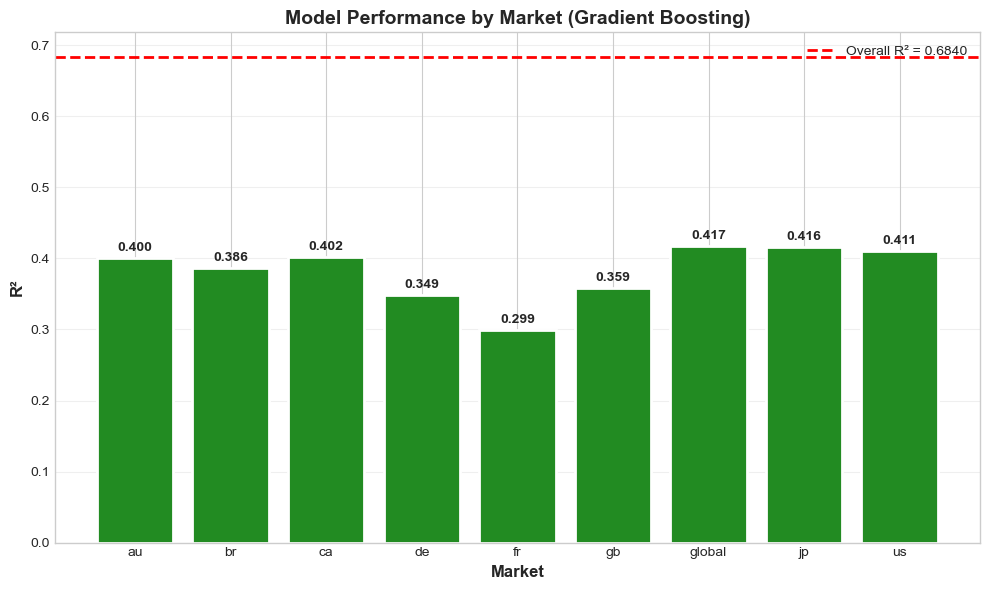

In [13]:
test_df = df.loc[X_test.index].copy()
test_df['y_pred'] = best_y_pred
test_df['y_actual'] = y_test.values

market_r2 = {}
for market in sorted(test_df['market'].unique()):
    mask = test_df['market'] == market
    y_true_market = test_df.loc[mask, 'y_actual']
    y_pred_market = test_df.loc[mask, 'y_pred']
    r2 = r2_score(y_true_market, y_pred_market)
    market_r2[market] = r2
    print(f"{market:8s}: R² = {r2:.4f} (n={mask.sum()})")

fig, ax = plt.subplots(figsize=(10, 6))
markets = list(market_r2.keys())
r2s = list(market_r2.values())

bars = ax.bar(markets, r2s, color='forestgreen', edgecolor='white', linewidth=2)
for bar, r2 in zip(bars, r2s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{r2:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.axhline(best_test_r2, color='red', linestyle='--', linewidth=2,
           label=f'Overall R² = {best_test_r2:.4f}')
ax.set_xlabel('Market', fontsize=12, fontweight='bold')
ax.set_ylabel('R²', fontsize=12, fontweight='bold')
ax.set_title(f'Model Performance by Market ({best_model_name})',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Genre Family Analysis

Analyze how genre families affect prediction performance:
1. **Performance by genre family** - Which families are easiest to predict?
2. **Distance effect by family** - Does distance help more for some families?
3. **Within vs Cross-family** - Are cross-family collaborations different?

In [14]:
FAMILIES = {
    'Pop': ['pop', 'dance pop', 'canadian pop', 'uk pop', 'post-teen pop',
            'electropop', 'indie pop', 'viral pop', 'art pop',
            'indie poptimism', 'bedroom pop', 'singer-songwriter pop',
            'australian pop', 'barbadian pop', 'boy band', 'talent show'],
    'Rap': ['rap', 'pop rap', 'melodic rap', 'dfw rap', 'cloud rap',
            'gangster rap', 'west coast rap', 'queens hip hop',
            'miami hip hop', 'chicago rap', 'conscious hip hop',
            'detroit hip hop', 'underground hip hop', 'british hip hop'],
    'Hip Hop': ['hip hop', 'trap', 'canadian hip hop', 'southern hip hop',
                'atl hip hop', 'toronto rap', 'urban contemporary',
                'french hip hop', 'german hip hop', 'uk hip hop',
                'old school hip hop', 'alternative hip hop', 'instrumental hip hop'],
    'Rock': ['rock', 'modern rock', 'classic rock', 'alternative rock',
             'hard rock', 'post-grunge', 'album rock', 'soft rock',
             'indie rock', 'folk rock', 'pop rock', 'alternative metal',
             'permanent wave', 'rock-and-roll', 'garage rock'],
    'Latin': ['urbano latino', 'trap latino', 'reggaeton', 'latin pop',
              'puerto rican pop', 'reggaeton flow', 'latin hip hop',
              'reggaeton colombiano', 'spanish hip hop', 'latin arena pop',
              'musica mexicana', 'sierreno', 'latin', 'corrido', 'banda',
              'norteno', 'sad sierreno', 'latin alternative'],
}

genre_to_family = {}
for family_name, genres in FAMILIES.items():
    for genre in genres:
        genre_to_family[genre] = family_name

test_df_families = df.loc[X_test.index].copy()
test_df_families['family_source'] = test_df_families['source'].map(genre_to_family)
test_df_families['family_target'] = test_df_families['target'].map(genre_to_family)

test_df_families['collab_type'] = np.where(
    test_df_families['family_source'] == test_df_families['family_target'],
    'Within-Family',
    'Cross-Family'
)

test_df_families['has_isolated'] = (
    test_df_families['family_source'].isna() | 
    test_df_families['family_target'].isna()
)

test_df_families['y_actual'] = y_test.values
test_df_families['y_pred'] = best_y_pred

WITHIN-FAMILY vs CROSS-FAMILY COLLABORATIONS

T-test comparing prediction errors:
  Mean error (within-family): 0.2639
  Mean error (cross-family):  0.3382
  t-statistic: -6.7155
  p-value:     0.0000

→ Cross-family collaborations are SIGNIFICANTLY HARDER to predict


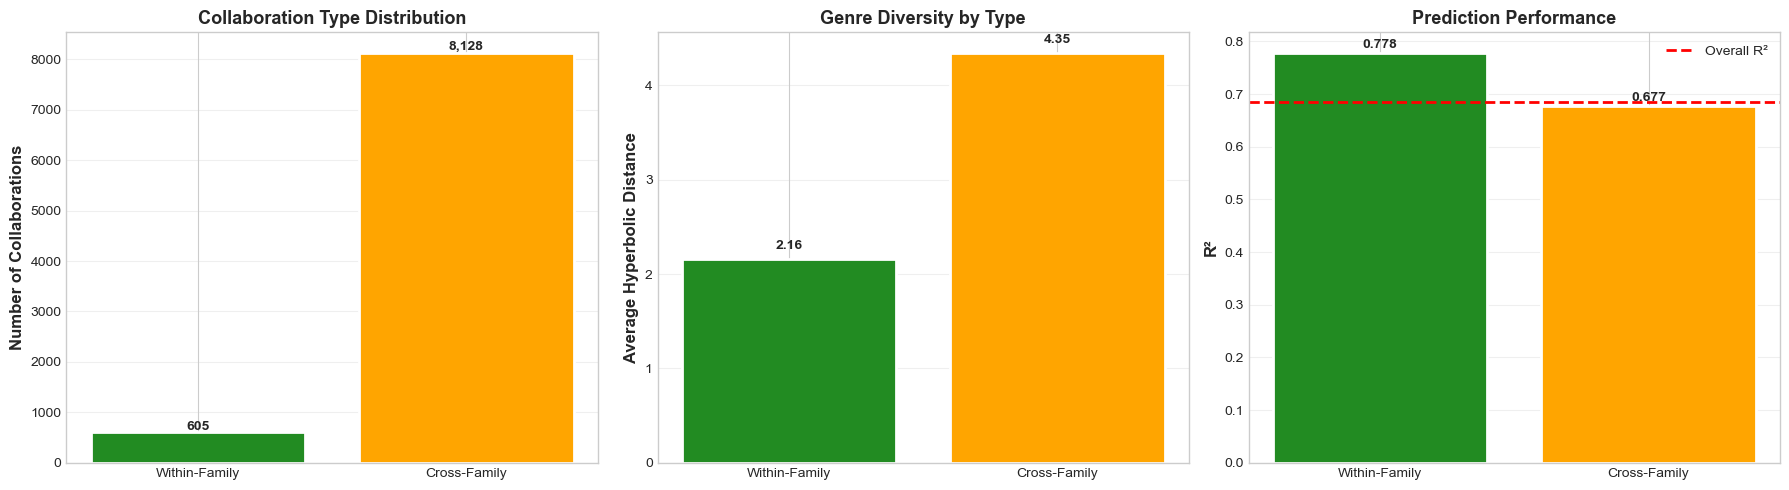

In [15]:
# Analysis 1: Within-Family vs Cross-Family Collaborations

print("="*70)
print("WITHIN-FAMILY vs CROSS-FAMILY COLLABORATIONS")
print("="*70)

comparison_data = []

for collab_type in ['Within-Family', 'Cross-Family']:
    mask = test_df_families['collab_type'] == collab_type
    subset = test_df_families[mask]
    
    r2 = r2_score(subset['y_actual'], subset['y_pred'])
    avg_distance = subset.loc[subset.index, 'distance'].mean()
    avg_actual = subset['y_actual'].mean()
    
    comparison_data.append({
        'Type': collab_type,
        'Count': len(subset),
        'Avg Distance': avg_distance,
        'Avg Success (log)': avg_actual,
        'Model R²': r2
    })

comparison_df = pd.DataFrame(comparison_data)
within_errors = np.abs(test_df_families[test_df_families['collab_type'] == 'Within-Family']['y_actual'] - 
                       test_df_families[test_df_families['collab_type'] == 'Within-Family']['y_pred'])
cross_errors = np.abs(test_df_families[test_df_families['collab_type'] == 'Cross-Family']['y_actual'] - 
                      test_df_families[test_df_families['collab_type'] == 'Cross-Family']['y_pred'])

t_stat, p_val = scipy_stats.ttest_ind(within_errors, cross_errors)

print(f"\nT-test comparing prediction errors:")
print(f"  Mean error (within-family): {within_errors.mean():.4f}")
print(f"  Mean error (cross-family):  {cross_errors.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_val:.4f}")

if p_val < 0.05:
    if cross_errors.mean() > within_errors.mean():
        print("\n→ Cross-family collaborations are SIGNIFICANTLY HARDER to predict")
    else:
        print("\n→ Within-family collaborations are SIGNIFICANTLY HARDER to predict")
else:
    print("\n→ NO SIGNIFICANT DIFFERENCE in prediction difficulty")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Count
axes[0].bar(comparison_df['Type'], comparison_df['Count'],
            color=['forestgreen', 'orange'], edgecolor='white', linewidth=2)
axes[0].set_ylabel('Number of Collaborations', fontsize=12, fontweight='bold')
axes[0].set_title('Collaboration Type Distribution', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['Count']):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Average Distance
axes[1].bar(comparison_df['Type'], comparison_df['Avg Distance'],
            color=['forestgreen', 'orange'], edgecolor='white', linewidth=2)
axes[1].set_ylabel('Average Hyperbolic Distance', fontsize=12, fontweight='bold')
axes[1].set_title('Genre Diversity by Type', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['Avg Distance']):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# Plot 3: Model R²
axes[2].bar(comparison_df['Type'], comparison_df['Model R²'],
            color=['forestgreen', 'orange'], edgecolor='white', linewidth=2)
axes[2].set_ylabel('R²', fontsize=12, fontweight='bold')
axes[2].set_title('Prediction Performance', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
axes[2].axhline(best_test_r2, color='red', linestyle='--', linewidth=2, label='Overall R²')
axes[2].legend()
for i, v in enumerate(comparison_df['Model R²']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


SUMMARY: Distance Improvement by Family
 Family  n_test  R² Without  R² With  Improvement
   Rock     390    0.515988 0.639592     0.123604
Hip Hop    1914    0.446512 0.506226     0.059714
    Rap    2177    0.573925 0.629261     0.055336
    Pop    2880    0.566960 0.609897     0.042937
  Latin     569    0.532658 0.572268     0.039610


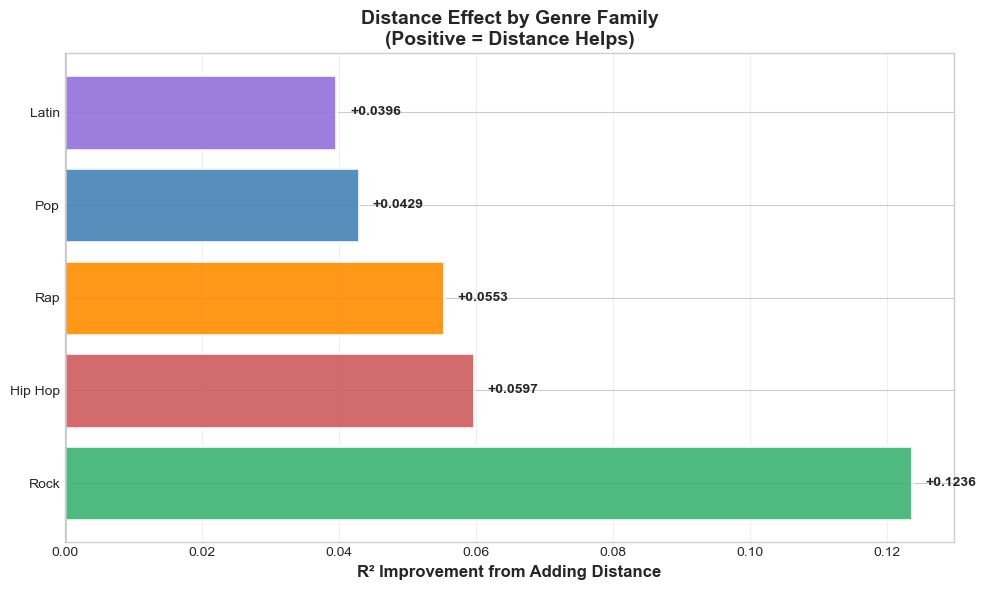


INTERPRETATION

Distance helps MOST for Rock (+0.1236)
Distance helps LEAST for Latin (+0.0396)

→ Genre diversity information is particularly valuable for Rock collaborations


In [16]:
# Analysis 2: Distance Effect by Genre Family

family_distance_results = []

train_df_families = df.loc[X_train.index].copy()
train_df_families['family_source'] = train_df_families['source'].map(genre_to_family)

for family in FAMILIES.keys():
   
    train_mask = (train_df_families['family_source'] == family)
    test_mask = (test_df_families['family_source'] == family) | \
                (test_df_families['family_target'] == family)
    
    X_train_family = X_train[train_mask]
    y_train_family = y_train[train_mask]
    X_test_family = X_test[test_mask]
    y_test_family = y_test[test_mask]
    
    # Model WITH distance
    model_with = GradientBoostingRegressor(**best_params, random_state=42)
    model_with.fit(X_train_family, y_train_family)
    r2_with = r2_score(y_test_family, model_with.predict(X_test_family))
    
    # Model WITHOUT distance
    X_train_no_dist = X_train_family[FEATURES_NO_DIST]
    X_test_no_dist = X_test_family[FEATURES_NO_DIST]
    
    model_without = GradientBoostingRegressor(**best_params, random_state=42)
    model_without.fit(X_train_no_dist, y_train_family)
    r2_without = r2_score(y_test_family, model_without.predict(X_test_no_dist))
    
    improvement = r2_with - r2_without
    
    family_distance_results.append({
        'Family': family,
        'n_test': test_mask.sum(),
        'R² Without': r2_without,
        'R² With': r2_with,
        'Improvement': improvement
    })
    

family_dist_df = pd.DataFrame(family_distance_results).sort_values('Improvement', ascending=False)

print("\n" + "="*70)
print("SUMMARY: Distance Improvement by Family")
print("="*70)
print(family_dist_df.to_string(index=False))


family_colors = {
    'Pop': '#4682b4',      
    'Rap': '#ff8c00',      
    'Hip Hop': '#cd5c5c',  
    'Rock': '#3cb371',     
    'Latin': '#9370db'     
}

fig, ax = plt.subplots(figsize=(10, 6))

colors = [family_colors[family] for family in family_dist_df['Family']]
bars = ax.barh(family_dist_df['Family'], family_dist_df['Improvement'],
               color=colors, edgecolor='white', linewidth=2, alpha=0.9)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('R² Improvement from Adding Distance', fontsize=12, fontweight='bold')
ax.set_title('Distance Effect by Genre Family\n(Positive = Distance Helps)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, family_dist_df['Improvement'])):
    ax.text(val + 0.002 if val > 0 else val - 0.002, i,
            f'{val:+.4f}', va='center',
            ha='left' if val > 0 else 'right',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
best_family = family_dist_df.iloc[0]
worst_family = family_dist_df.iloc[-1]

print(f"\nDistance helps MOST for {best_family['Family']} (+{best_family['Improvement']:.4f})")
print(f"Distance helps LEAST for {worst_family['Family']} ({worst_family['Improvement']:+.4f})")
print(f"\n→ Genre diversity information is particularly valuable for {best_family['Family']} collaborations")